In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

df = pd.read_csv('/content/BankChurners_Cleaned.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10127, 23)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Education_Level_missing_flag,Marital_Status_missing_flag,Income_Category_missing_flag
0,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,777,11914.0,1.335,1144,42,1.625,0.061,0,0,0
1,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,864,7392.0,1.541,1291,33,3.714,0.105,0,0,0
2,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,0,3418.0,2.594,1887,20,2.333,0.000,0,0,0
3,0,40,F,4,High School,Missing,Less than $40K,Blue,34,3,...,2517,796.0,1.405,1171,20,2.333,0.760,0,1,0
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,0,4716.0,2.175,816,28,2.500,0.000,0,0,0


In [3]:
# Data types
print("\nData Types:\n")
print(df.dtypes)

# Missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n")
print(df.describe())


Data Types:

Attrition_Flag                    int64
Customer_Age                      int64
Gender                           object
Dependent_count                   int64
Education_Level                  object
Marital_Status                   object
Income_Category                  object
Card_Category                    object
Months_on_book                    int64
Total_Relationship_Count          int64
Months_Inactive_12_mon            int64
Contacts_Count_12_mon             int64
Credit_Limit                    float64
Total_Revolving_Bal               int64
Avg_Open_To_Buy                 float64
Total_Amt_Chng_Q4_Q1            float64
Total_Trans_Amt                   int64
Total_Trans_Ct                    int64
Total_Ct_Chng_Q4_Q1             float64
Avg_Utilization_Ratio           float64
Education_Level_missing_flag      int64
Marital_Status_missing_flag       int64
Income_Category_missing_flag      int64
dtype: object

Missing Values:

Attrition_Flag                  0


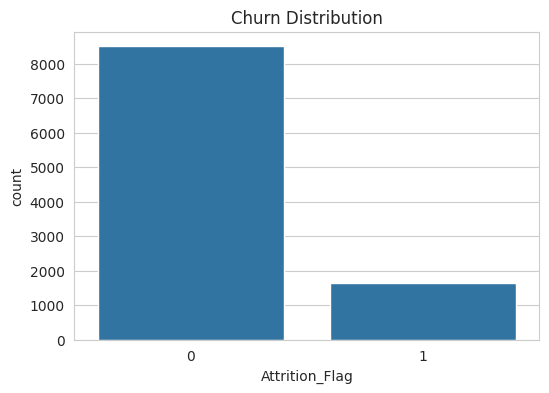

Attrition_Flag
0    83.934038
1    16.065962
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition_Flag', data=df)
plt.title("Churn Distribution")
plt.show()

print(df['Attrition_Flag'].value_counts(normalize=True) * 100)

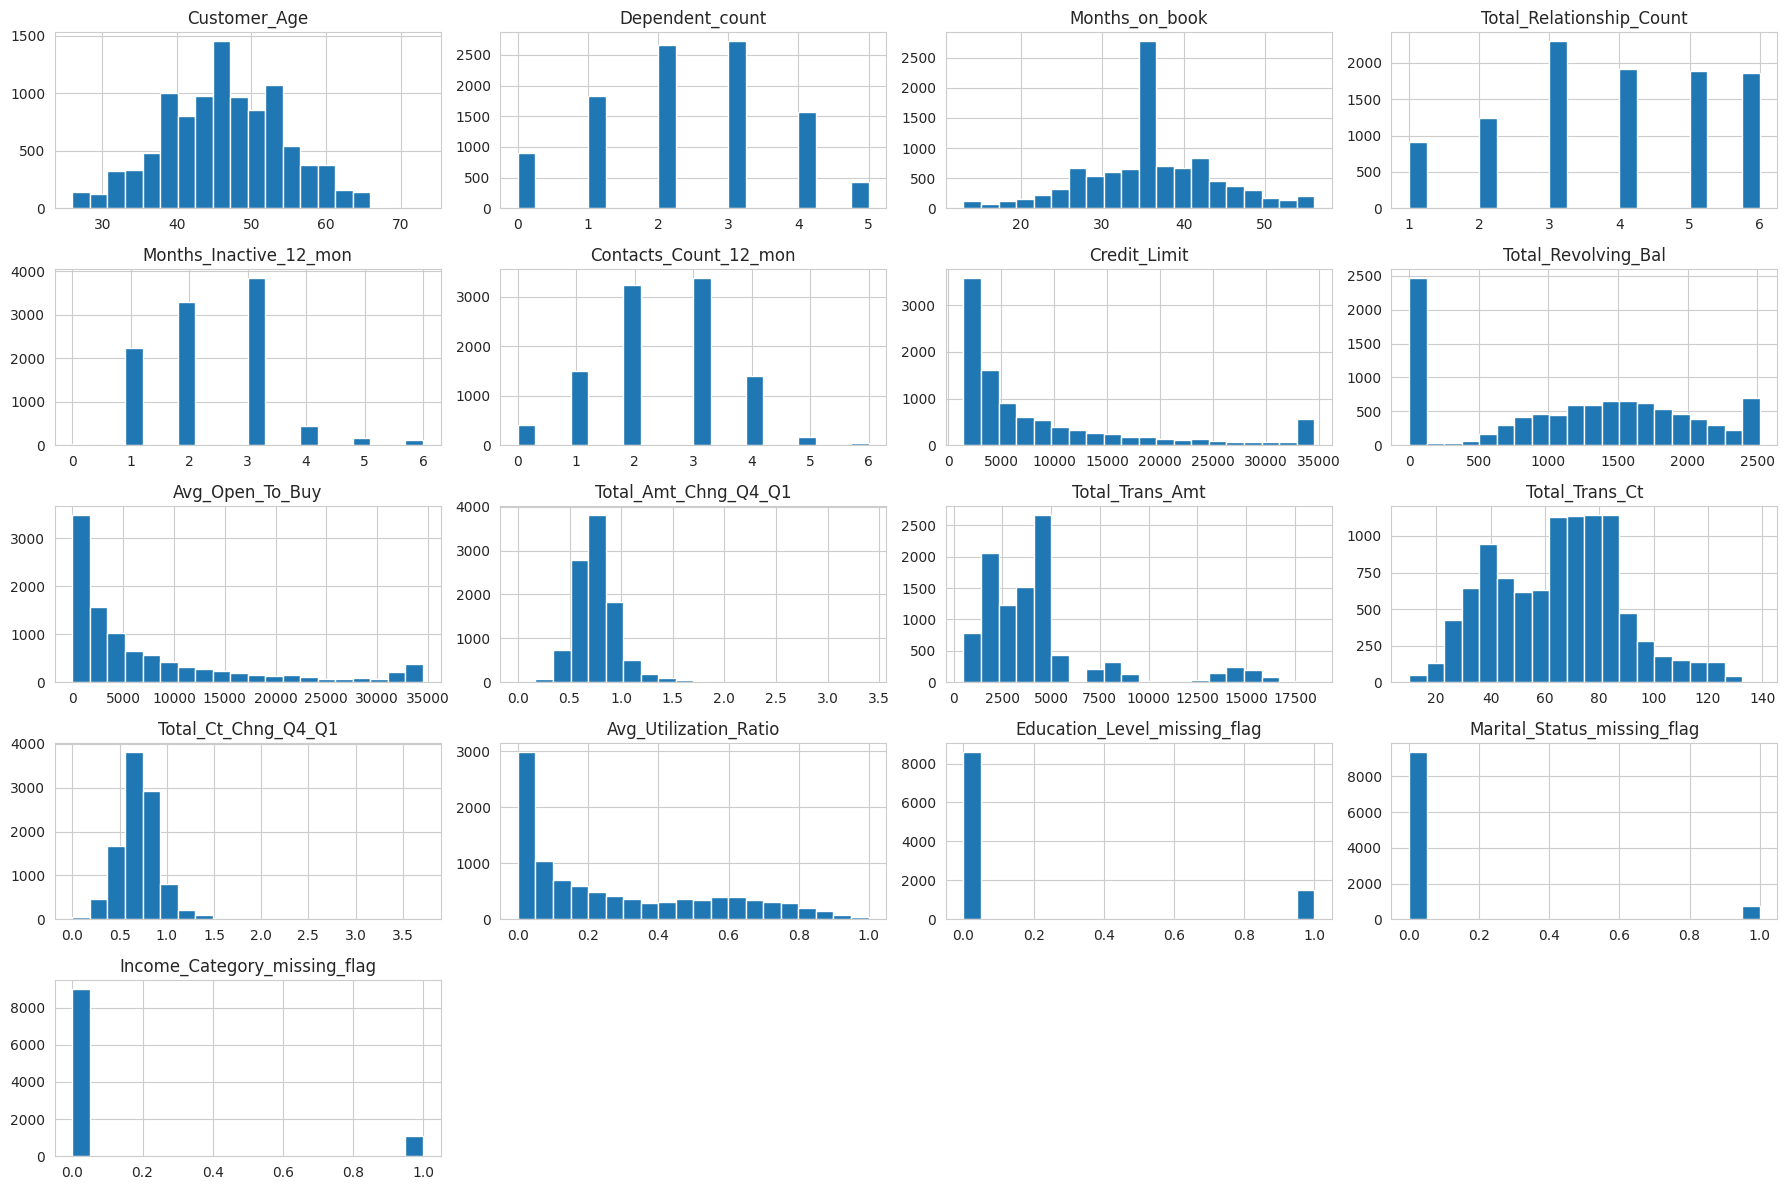

In [5]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('Attrition_Flag')

df[num_cols].hist(figsize=(18,12), bins=20)
plt.tight_layout()
plt.show()

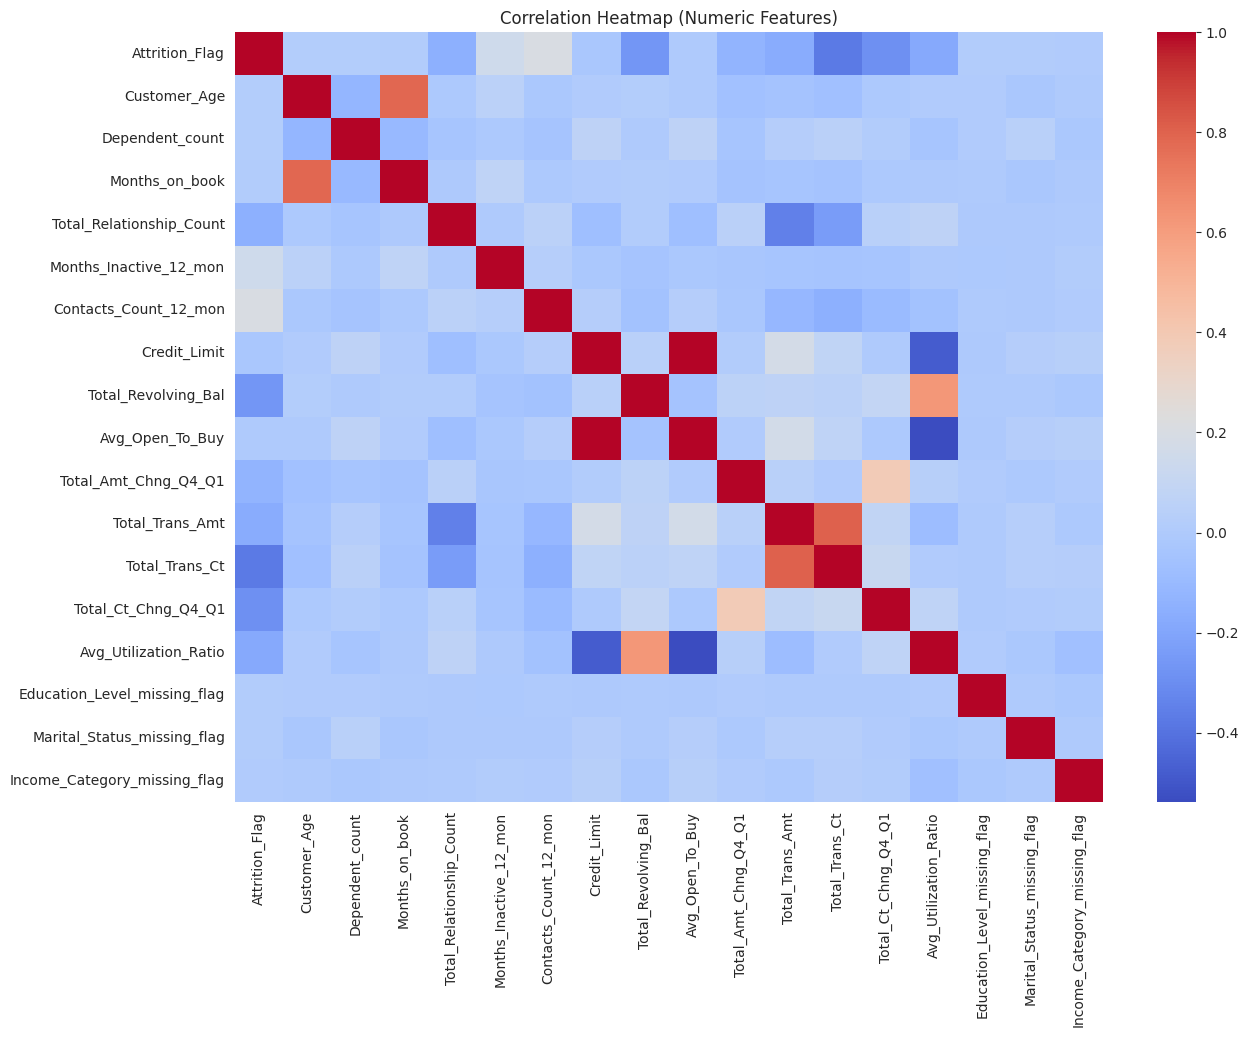

In [8]:
# Correlation heatmap
plt.figure(figsize=(14,10))

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')

plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

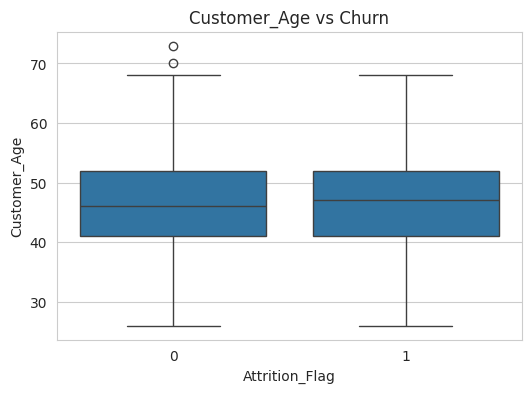

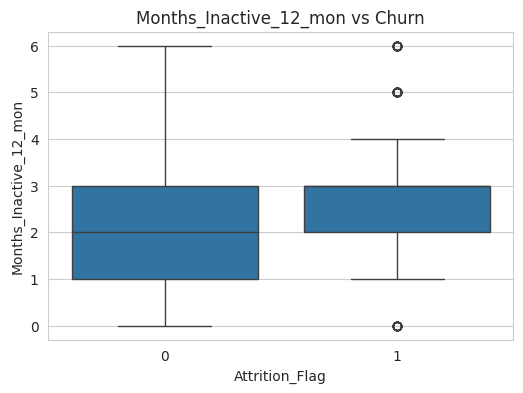

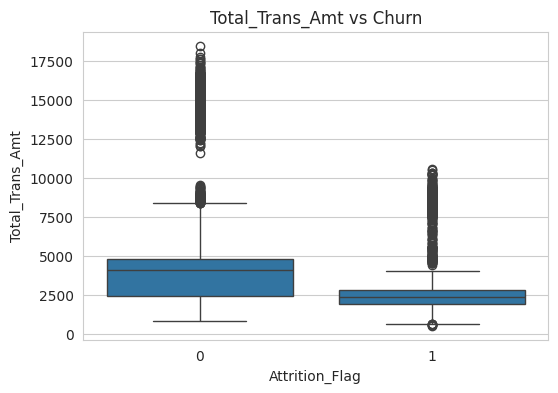

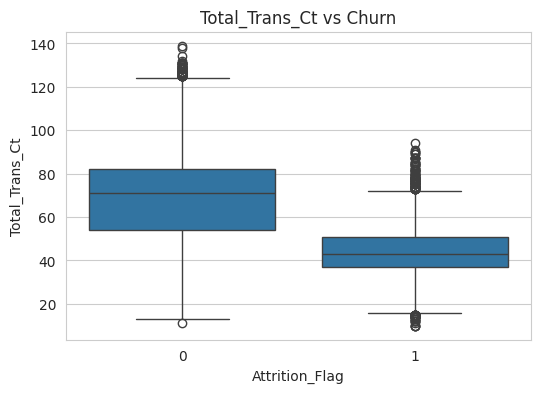

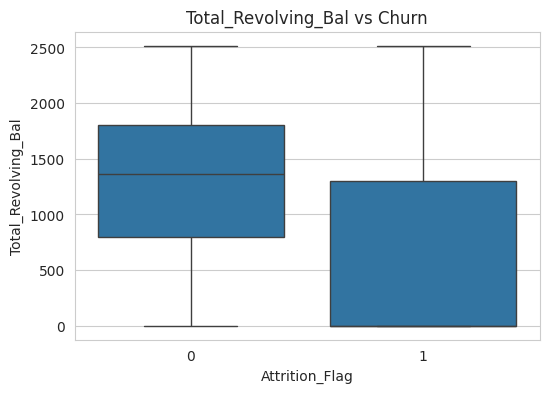

In [9]:
important_num = [
    'Customer_Age',
    'Months_Inactive_12_mon',
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Total_Revolving_Bal'
]

for col in important_num:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Attrition_Flag', y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

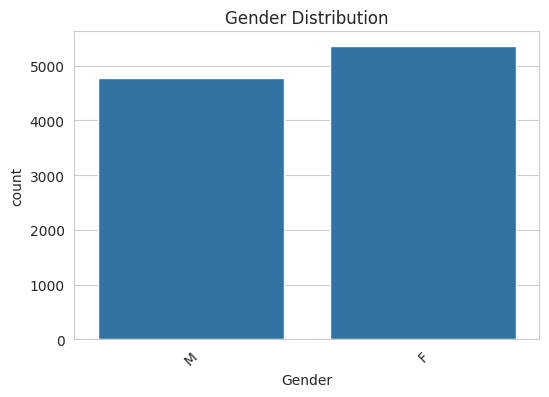

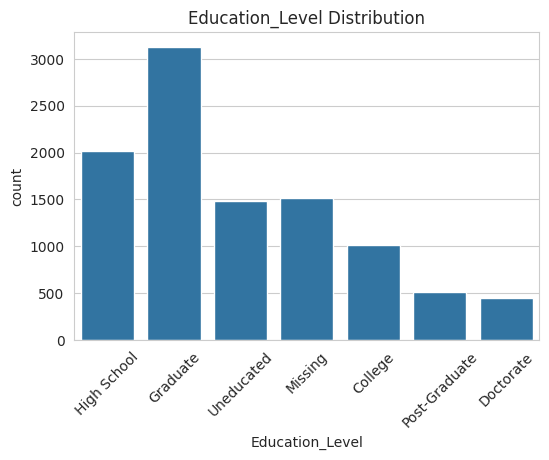

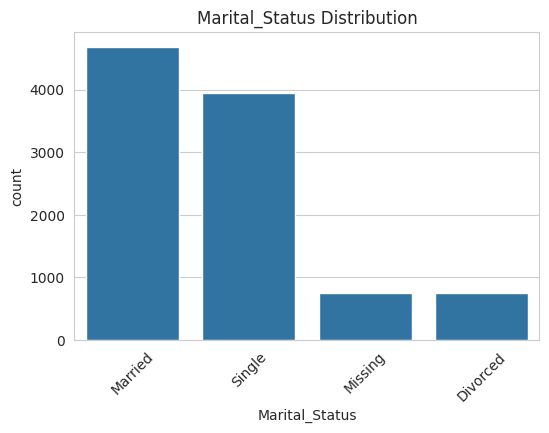

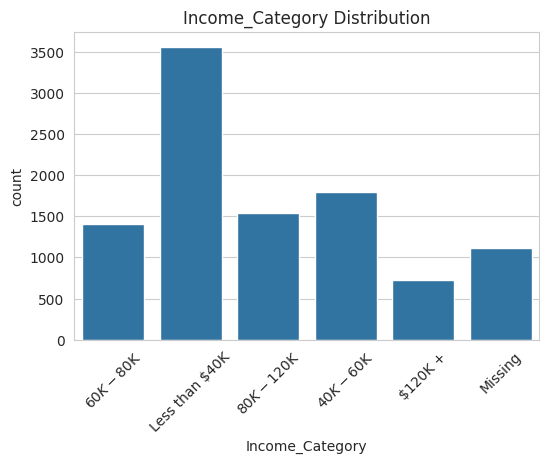

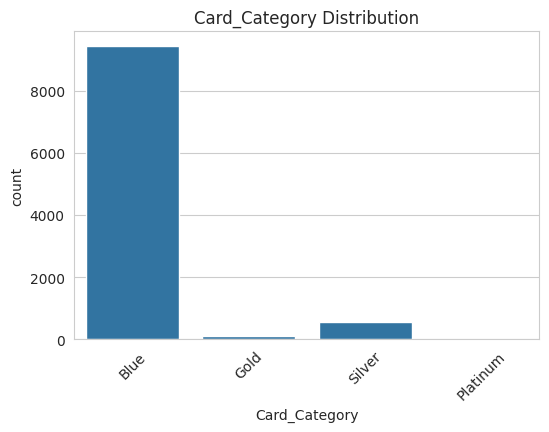

In [10]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} Distribution")
    plt.show()

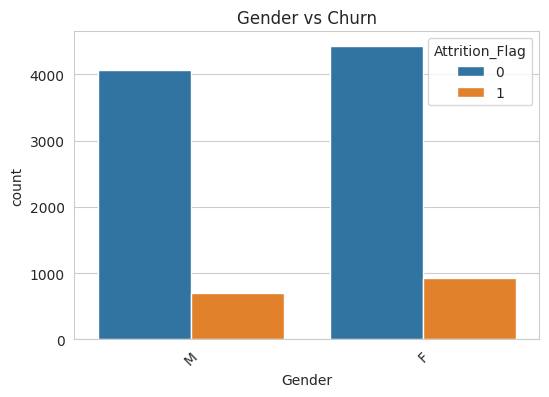

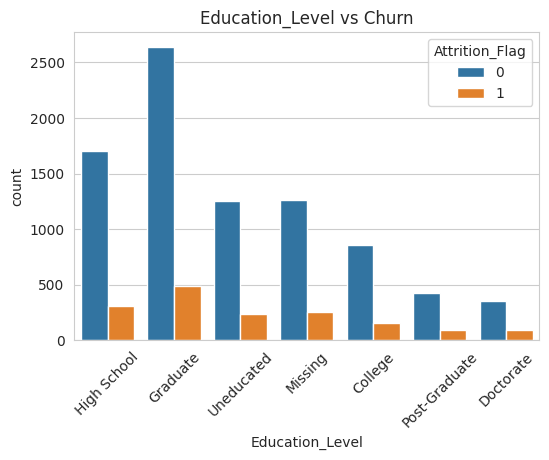

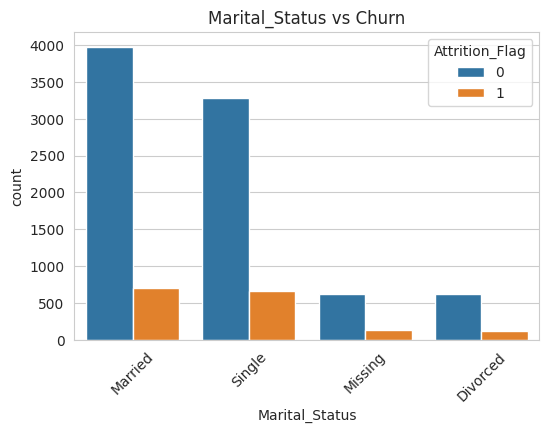

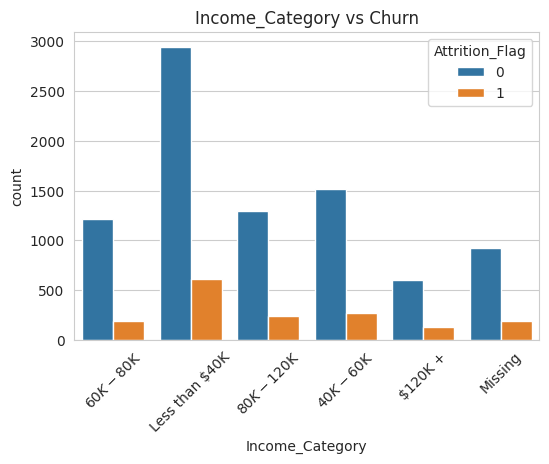

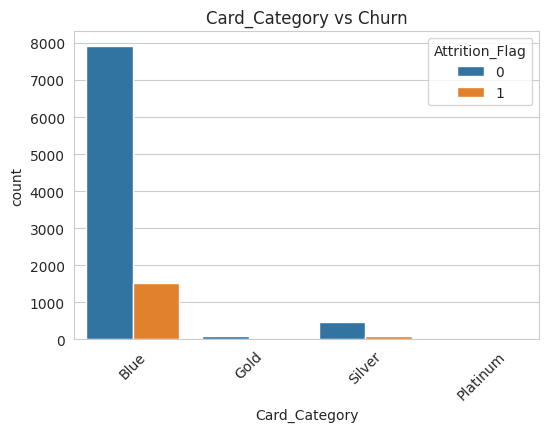

In [11]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Attrition_Flag', data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Churn")
    plt.show()

In [12]:
for col in cat_cols:
    print(f"\nChurn Rate by {col}:")
    print(pd.crosstab(df[col], df['Attrition_Flag'], normalize='index') * 100)


Churn Rate by Gender:
Attrition_Flag          0          1
Gender                              
F               82.642777  17.357223
M               85.384777  14.615223

Churn Rate by Education_Level:
Attrition_Flag           0          1
Education_Level                      
College          84.797631  15.202369
Doctorate        78.935698  21.064302
Graduate         84.430946  15.569054
High School      84.798808  15.201192
Missing          83.146807  16.853193
Post-Graduate    82.170543  17.829457
Uneducated       84.061870  15.938130

Churn Rate by Marital_Status:
Attrition_Flag          0          1
Marital_Status                      
Divorced        83.823529  16.176471
Married         84.873053  15.126947
Missing         82.777036  17.222964
Single          83.058585  16.941415

Churn Rate by Income_Category:
Attrition_Flag           0          1
Income_Category                      
$120K +          82.668501  17.331499
$40K - $60K      84.860335  15.139665
$60K - $80K      8

In [13]:
churn_rate = df['Attrition_Flag'].mean() * 100
print(f"\nOverall Churn Rate: {churn_rate:.2f}%")


Overall Churn Rate: 16.07%
